# Đánh giá mô hình Spatial Transformer (DF_FusionModel) trên tập Test
Notebook này dùng để đánh giá mô hình Spatial Transformer, tạo các biểu đồ chuyên nghiệp (ROC, Confusion Matrix, FAR/FRR) tương tự như Xception baseline.

**Yêu cầu:**
1. Cài đặt **Accelerator -> GPU**.
2. **Add Input** -> Chọn Dataset chứa frame đã crop (ví dụ: `ffpp-c23-face-cache`).
3. **Add Input** -> Chọn Dataset chứa file weights `.pth` và `train_history.csv` của mô hình Spatial.
4. Cập nhật các đường dẫn tương ứng ở cell dưới.

In [1]:
import os, glob, random, json
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

# ==================== CẤU HÌNH ĐƯỜNG DẪN ====================
CACHE_DIR = "/kaggle/input/datasets/thinhphan272/ffpp-c23-face-cache/ffpp_c23_cache"
MANIFEST_CSV = os.path.join(CACHE_DIR, "manifest_processed.csv")

# Thay đổi các đường dẫn này trỏ tới bộ dataset chứa file pth và csv của Spatial
WEIGHTS_PATH = "/kaggle/input/datasets/thinhphan1506/dffusion-trained-pth/spatial_transformer/spatial_transformer_best.pth"
HISTORY_CSV = "/kaggle/input/datasets/thinhphan1506/dffusionmodel-trainhistory-csv/train_history.csv"

IMG_SIZE = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

OUT_DIR = "/kaggle/working/spatial_eval_charts"
os.makedirs(OUT_DIR, exist_ok=True)
print("Device:", DEVICE)

Device: cuda


In [2]:
manifest = pd.read_csv(MANIFEST_CSV)
manifest = manifest[manifest["status"].isin(["ok", "skip_exists"])].reset_index(drop=True)
manifest['out_dir'] = manifest['out_dir'].str.replace('/kaggle/working/ffpp_c23_cache', CACHE_DIR)

test_df = manifest[manifest.split == "test"].reset_index(drop=True)
print(f"Total Test videos: {len(test_df)}")

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def load_and_preprocess(img_path, img_size=IMG_SIZE):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img = (img.astype(np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(img.transpose(2, 0, 1)).float()

class FFPPVideoEvalDataset(Dataset):
    def __init__(self, df, img_size=IMG_SIZE):
        self.rows = []
        for row in df.itertuples():
            frame_files = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
            if len(frame_files) > 0: self.rows.append((row.video_id, frame_files, row.label))
        self.img_size = img_size
    def __len__(self): return len(self.rows)
    def __getitem__(self, idx):
        vid, frame_files, label = self.rows[idx]
        imgs = torch.stack([load_and_preprocess(f, self.img_size) for f in frame_files])
        return imgs, torch.tensor(label, dtype=torch.float32), vid

test_ds = FFPPVideoEvalDataset(test_df)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2)
print(f"Test Dataset loaded successfully: {len(test_ds)} videos")

Total Test videos: 700
Test Dataset loaded successfully: 700 videos


In [3]:
!pip install -q timm seaborn scipy
import timm

BACKBONE_NAME = "swin_base_patch4_window7_224"
DROP_PATH_RATE = 0.2

class SpatialTransformerDetector(nn.Module):
    def __init__(self, backbone_name=BACKBONE_NAME, pretrained=False, drop_path_rate=DROP_PATH_RATE):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name, pretrained=pretrained, num_classes=0, drop_path_rate=drop_path_rate
        )
        feat_dim = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        feat = self.backbone(x)
        return self.classifier(feat).squeeze(-1)

model = SpatialTransformerDetector(pretrained=False).to(DEVICE)
print("SpatialTransformerDetector initialized.")

SpatialTransformerDetector initialized.


In [4]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix, auc
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def calc_eer(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    return eer

def find_eer_threshold(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fnr - fpr)))
    return float(thresholds[idx])

def calc_far_frr(y_true, y_score, threshold):
    y_true = np.asarray(y_true)
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    far = fn / (fn + tp) if (fn + tp) > 0 else float("nan")
    frr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
    return far, frr, cm

def calc_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    auc_val = roc_auc_score(y_true, y_score)
    eer = calc_eer(y_true, y_score)
    acc = accuracy_score(y_true, (y_score >= threshold).astype(int))
    far_05, frr_05, cm_05 = calc_far_frr(y_true, y_score, threshold=0.5)
    eer_thr = find_eer_threshold(y_true, y_score)
    far_eer, frr_eer, cm_eer = calc_far_frr(y_true, y_score, threshold=eer_thr)
    return {
        "acc": acc, "auc": auc_val, "eer": eer,
        "far_at_0.5": far_05, "frr_at_0.5": frr_05, "cm_at_0.5": cm_05,
        "eer_threshold": eer_thr, "far_at_eer": far_eer, "frr_at_eer": frr_eer, "cm_at_eer": cm_eer,
    }

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    y_true, y_score = [], []
    for frames, label, _ in loader:
        logits = model(frames.squeeze(0).to(DEVICE))
        prob_video = torch.sigmoid(logits).mean().item()
        y_score.append(prob_video)
        y_true.append(label.item())
    return y_true, y_score, calc_metrics(y_true, y_score)

In [5]:
# Load weights
if os.path.exists(WEIGHTS_PATH):
    checkpoint = torch.load(WEIGHTS_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state'] if 'model_state' in checkpoint else checkpoint)
    print("Weights loaded successfully!")
else:
    print(f"Weights file not found at {WEIGHTS_PATH}. Please ensure the path is correct.")

print("\nRunning evaluation on test set, please wait...")
y_true, y_score, metrics = evaluate(model, test_loader)

print("\n=== BASIC EVALUATION METRICS ===")
print(f"Accuracy            : {metrics['acc']*100:.2f}%")
print(f"AUC                 : {metrics['auc']*100:.2f}%")
print(f"EER                 : {metrics['eer']*100:.2f}%")
print(f"FAR @ threshold=0.5 : {metrics['far_at_0.5']*100:.2f}%")
print(f"FRR @ threshold=0.5 : {metrics['frr_at_0.5']*100:.2f}%")
print(f"EER Threshold       : {metrics['eer_threshold']:.4f}")

Weights loaded successfully!

Running evaluation on test set, please wait...

=== BASIC EVALUATION METRICS ===
Accuracy            : 96.71%
AUC                 : 99.28%
EER                 : 2.86%
FAR @ threshold=0.5 : 2.14%
FRR @ threshold=0.5 : 7.86%
EER Threshold       : 0.6417


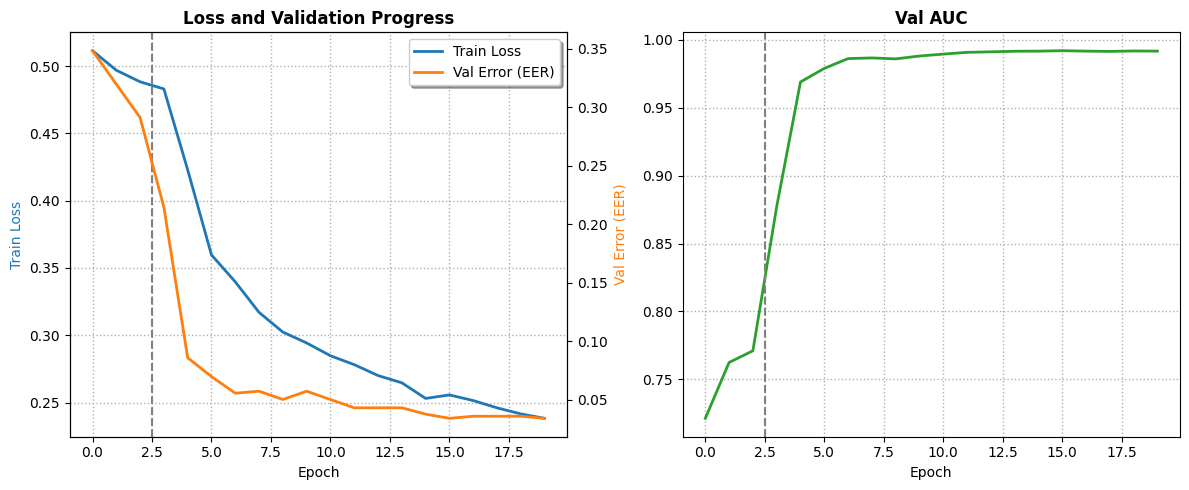

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

if os.path.exists(HISTORY_CSV):
    history_df = pd.read_csv(HISTORY_CSV)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    if 'train_loss' in history_df.columns and 'val_eer' in history_df.columns:
        ax1 = axes[0]
        ax2 = ax1.twinx()
        
        l1 = ax1.plot(history_df["train_loss"], label='Train Loss', color='#1f77b4', linewidth=2)
        l2 = ax2.plot(history_df["val_eer"], label='Val Error (EER)', color='#ff7f0e', linewidth=2)
        
        ax1.set_title("Loss and Validation Progress", fontsize=12, fontweight='bold')
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Train Loss", color='#1f77b4')
        ax2.set_ylabel("Val Error (EER)", color='#ff7f0e')
        ax1.axvline(3 - 0.5, color="gray", linestyle="--")
        
        lines = l1 + l2
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, shadow=True, frameon=True, loc='upper right')
        ax1.grid(True, linestyle=':', linewidth=1)
        
    if 'val_auc' in history_df.columns:
        axes[1].plot(history_df["val_auc"], color='#2ca02c', linewidth=2)
        axes[1].set_title("Val AUC", fontsize=12, fontweight='bold')
        axes[1].set_xlabel("Epoch")
        axes[1].axvline(3 - 0.5, color="gray", linestyle="--")
        axes[1].grid(True, linestyle=':', linewidth=1)
        
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "training_history.png"))
    plt.show()
else:
    print(f"History CSV not found at {HISTORY_CSV}")

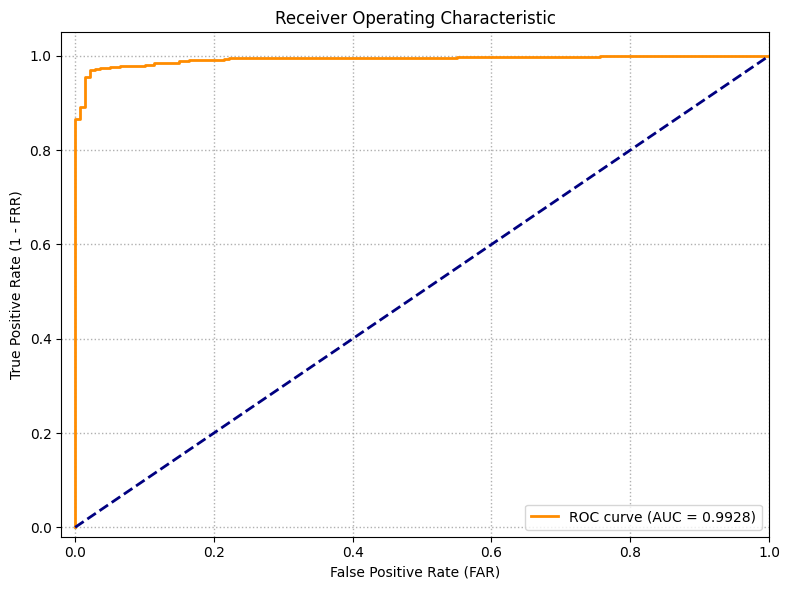

In [7]:
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.02, 1.0])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate (FAR)')
plt.ylabel('True Positive Rate (1 - FRR)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curve.png"), dpi=150)
plt.show()

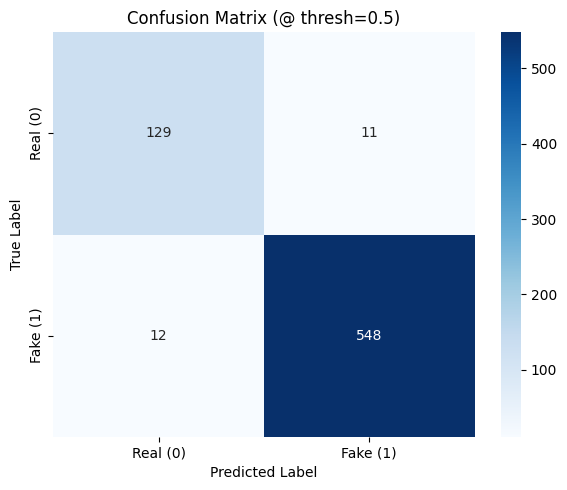

In [8]:
cm = metrics['cm_at_0.5']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=['Real (0)', 'Fake (1)'], 
            yticklabels=['Real (0)', 'Fake (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (@ thresh=0.5)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

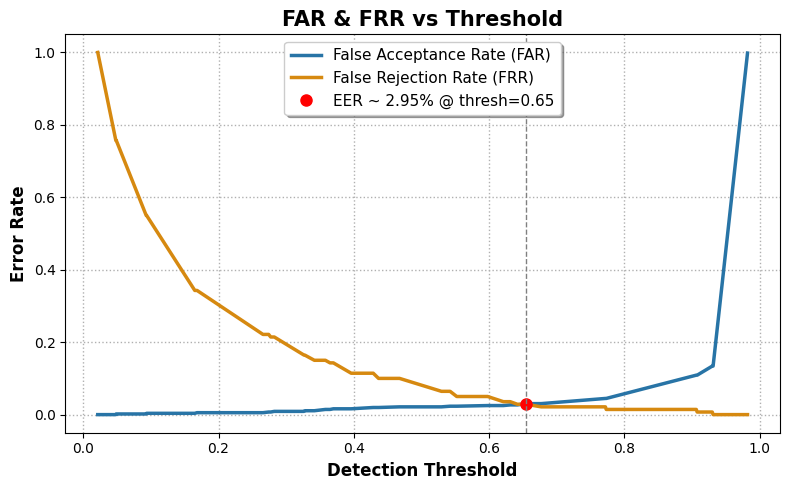

In [9]:
fars, frrs = [], []
for thresh in thresholds:
    preds = (np.array(y_score) >= thresh).astype(int)
    cm_t = confusion_matrix(y_true, preds, labels=[0, 1])
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    far_t = fn_t / (fn_t + tp_t) if (fn_t + tp_t) > 0 else 0
    frr_t = fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0
    fars.append(far_t)
    frrs.append(frr_t)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, fars, color="#2874A6", lw=2.5, label='False Acceptance Rate (FAR)')
plt.plot(thresholds, frrs, color="#D68910", lw=2.5, label='False Rejection Rate (FRR)')

idx_eer = np.argmin(np.abs(np.array(fars) - np.array(frrs)))
eer_thresh = thresholds[idx_eer]
eer_val = (fars[idx_eer] + frrs[idx_eer]) / 2

plt.plot(eer_thresh, eer_val, 'ro', markersize=8, label=f'EER ~ {eer_val*100:.2f}% @ thresh={eer_thresh:.2f}')
plt.axvline(x=eer_thresh, color='gray', linestyle='--', lw=1)

plt.xlabel('Detection Threshold', fontsize=12, fontweight='bold')
plt.ylabel('Error Rate', fontsize=12, fontweight='bold')
plt.title('FAR & FRR vs Threshold', fontsize=15, fontweight='bold')
plt.legend(loc="upper center", fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "far_frr_curve.png"), dpi=150)
plt.show()